In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


## Question 1: Who Gives the Most Money in Total?

In [2]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending = False)

Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
                   ...    
IRAN                    80
ST. LUCIA               50
CROATIA                 26
SLOVAKIA                20
ERITREA                  3
Name: Foreign Gift Amount, Length: 155, dtype: int64

The top donor is Qatar, with a total of $2,706,240,869 donated.

## Question 2: Which Country Initiates the Most Gifts by Count

In [3]:
df['Country of Giftor'].value_counts().head(5)

Country of Giftor
ENGLAND        3655
CHINA          2461
CANADA         2344
JAPAN          1896
SWITZERLAND    1676
Name: count, dtype: int64

The country that initiates the most gifts is England with 3655 total gifts. I'm not sure if this dataset separates the different countries of the UK, if not then the UK gives the most total gifts. 

## Question 3: Which Country Gives the Largest Gifts on Average

In [4]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].mean().sort_values(ascending = False)

Country of Giftor
BERMUDA      7.688837e+06
ECUADOR      3.985140e+06
QATAR        3.905109e+06
ANTIGUA      3.435545e+06
JERSEY       3.064589e+06
                 ...     
ST. LUCIA    5.000000e+01
IRAN         4.000000e+01
CROATIA      2.600000e+01
SLOVAKIA     2.000000e+01
ERITREA      3.000000e+00
Name: Foreign Gift Amount, Length: 155, dtype: float64

The country that gives the largest gifts on average is Bermuda (also part of the UK), with an average gift amount of 7.688 million. 

## Question 4: Which Institution Receives the Most Money in Total?

In [5]:
df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending = False)

Institution Name
Carnegie Mellon University               1477922504
Cornell University                       1289937761
Harvard University                        954803610
Massachusetts Institute of Technology     859071692
Yale University                           613441311
                                            ...    
Jacksonville State University                250000
Metropolitan State University                235439
University of California, Merced             182514
University of Central Oklahoma               160288
University of Jamestown                         500
Name: Foreign Gift Amount, Length: 318, dtype: int64

The institution that receives the most money in total is Carnegie Mellon University, with nearly 1.5 billion dollars received in foreign gifts. 

## Question 5: Which Institution Receives the Most Amount of Gifts by Count. 

C:\Users\micha\AppData\Local\Temp\ipykernel_36852\4141903543.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


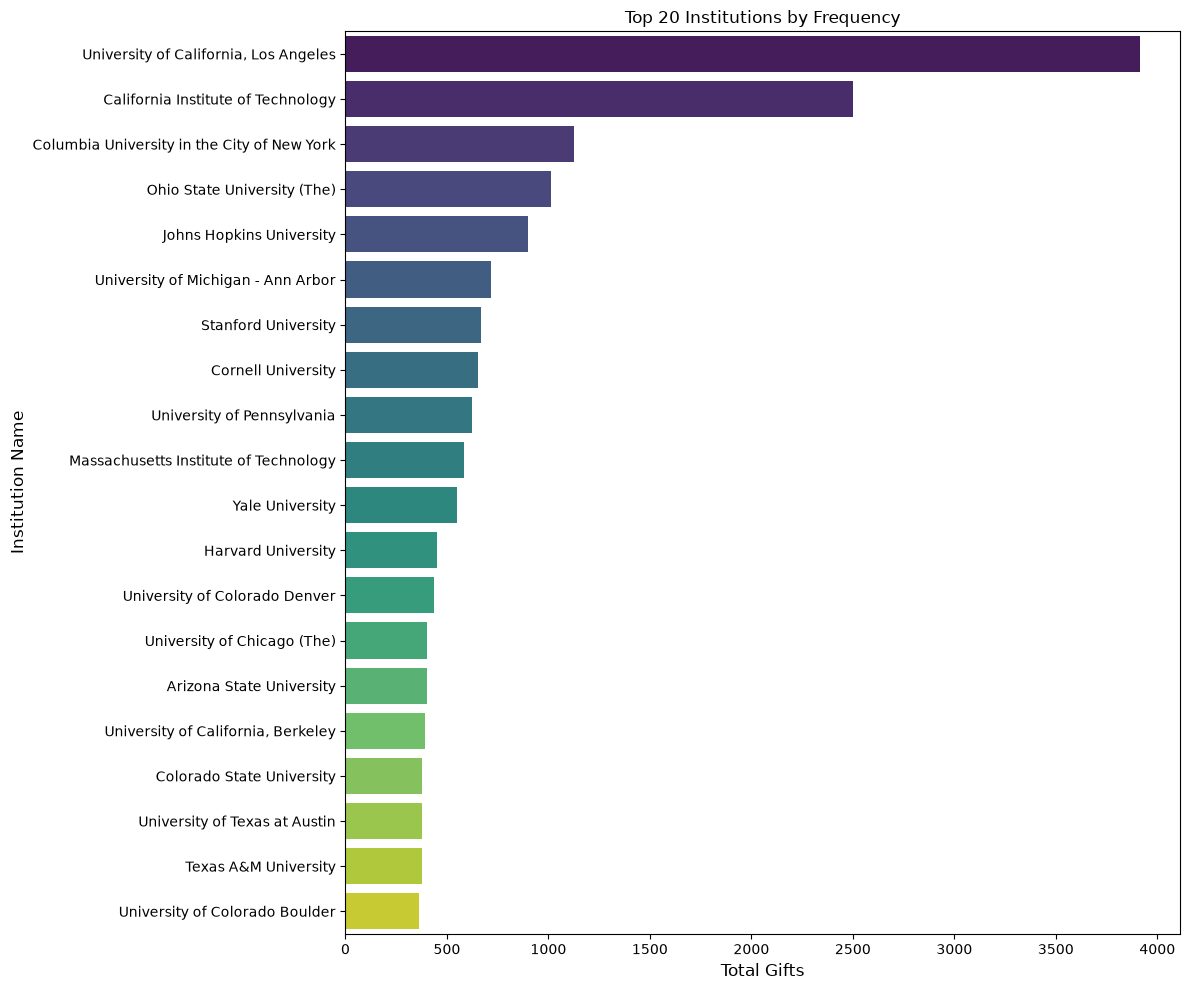

In [6]:
top_20_colleges = df["Institution Name"].value_counts().head(20).reset_index()

plt.figure(figsize=(12, 10))


sns.barplot(
    data=top_20_colleges,
    x="count",  
    y="Institution Name",  
    palette="viridis",  
)


plt.title("Top 20 Institutions by Frequency")
plt.xlabel("Total Gifts", fontsize=12)
plt.ylabel("Institution Name", fontsize=12)


plt.tight_layout()
plt.show()


In [7]:
print(top_20_colleges)

                               Institution Name  count
0         University of California, Los Angeles   3916
1            California Institute of Technology   2502
2   Columbia University in the City of New York   1127
3                   Ohio State University (The)   1014
4                      Johns Hopkins University    899
5            University of Michigan - Ann Arbor    715
6                           Stanford University    668
7                            Cornell University    653
8                    University of Pennsylvania    625
9         Massachusetts Institute of Technology    582
10                              Yale University    550
11                           Harvard University    453
12                University of Colorado Denver    436
13                  University of Chicago (The)    401
14                     Arizona State University    400
15           University of California, Berkeley    394
16                    Colorado State University    379
17        

UCLA has received the most gifts by total count, with 3916. Note that for the plot, I wanted a nice looking color gradient and I didn't know how to add it nor did I know the different gradient types, so the palette = "viridis" line is from claude.

## Question 6: What is the average amount each university receives? Median amount? If they are different, why?

C:\Users\micha\AppData\Local\Temp\ipykernel_36852\3181383692.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


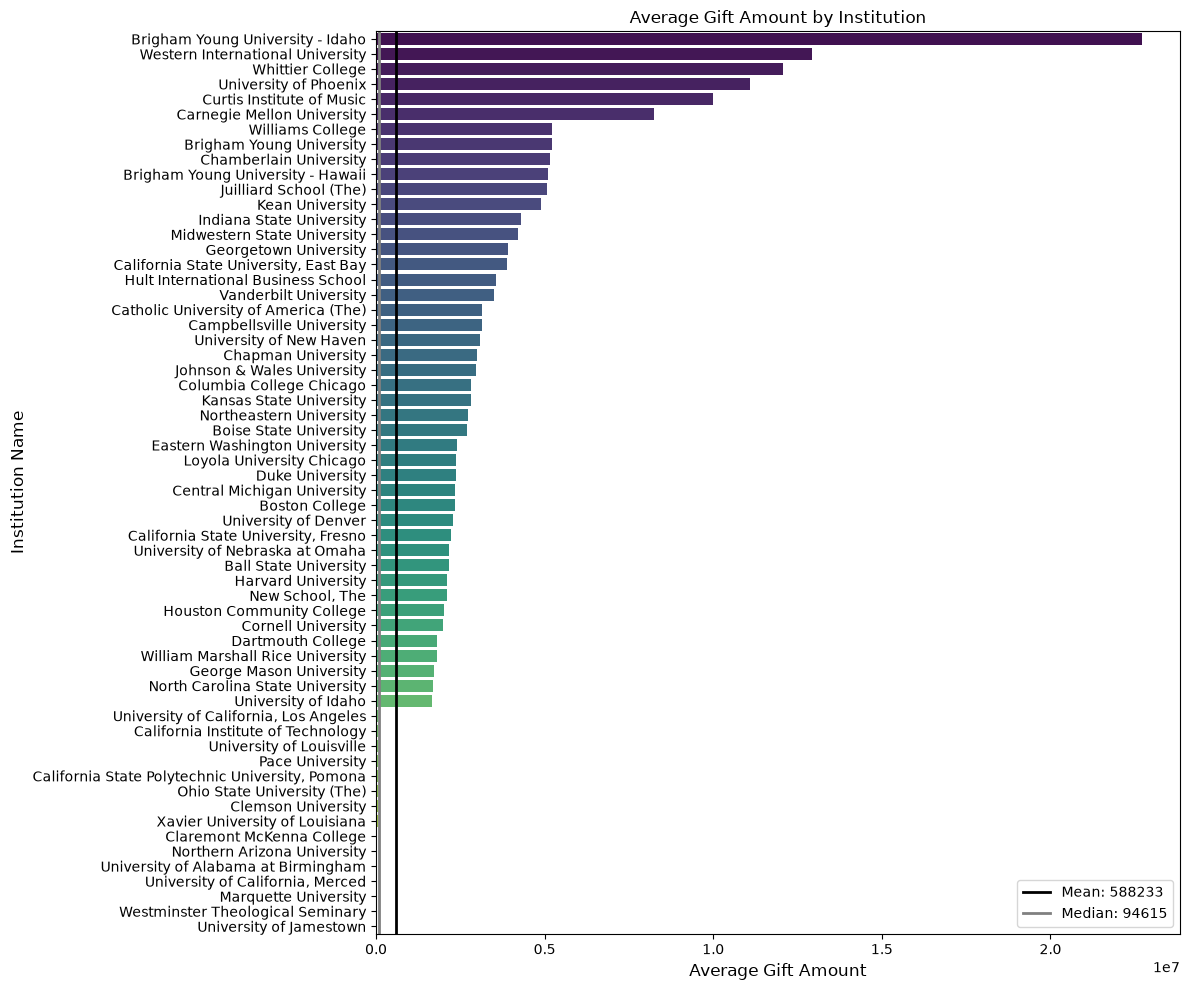

In [18]:
mean_gifts = df.groupby('Institution Name')['Foreign Gift Amount'].mean().sort_values(ascending=False)

top_45 = mean_gifts.head(45)
bottom_15 = mean_gifts.tail(15)
combined_means = pd.concat([top_45,bottom_15]).reset_index()

grand_mean = df['Foreign Gift Amount'].mean()
grand_median = df['Foreign Gift Amount'].median()

plt.figure(figsize=(12, 10))


sns.barplot(
    data= combined_means,
    x="Foreign Gift Amount",  
    y="Institution Name",  
    palette="viridis",  
)
plt.axvline(grand_mean, color='black', linewidth=2, label=f'Mean: {grand_mean:.0f}')
plt.axvline(grand_median, color='gray', linewidth=2, label=f'Median: {grand_median:.0f}')

plt.title("Average Gift Amount by Institution")
plt.xlabel("Average Gift Amount", fontsize=12)
plt.ylabel("Institution Name", fontsize=12)


plt.tight_layout()
plt.legend()
plt.show()

C:\Users\micha\AppData\Local\Temp\ipykernel_36852\1123507466.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


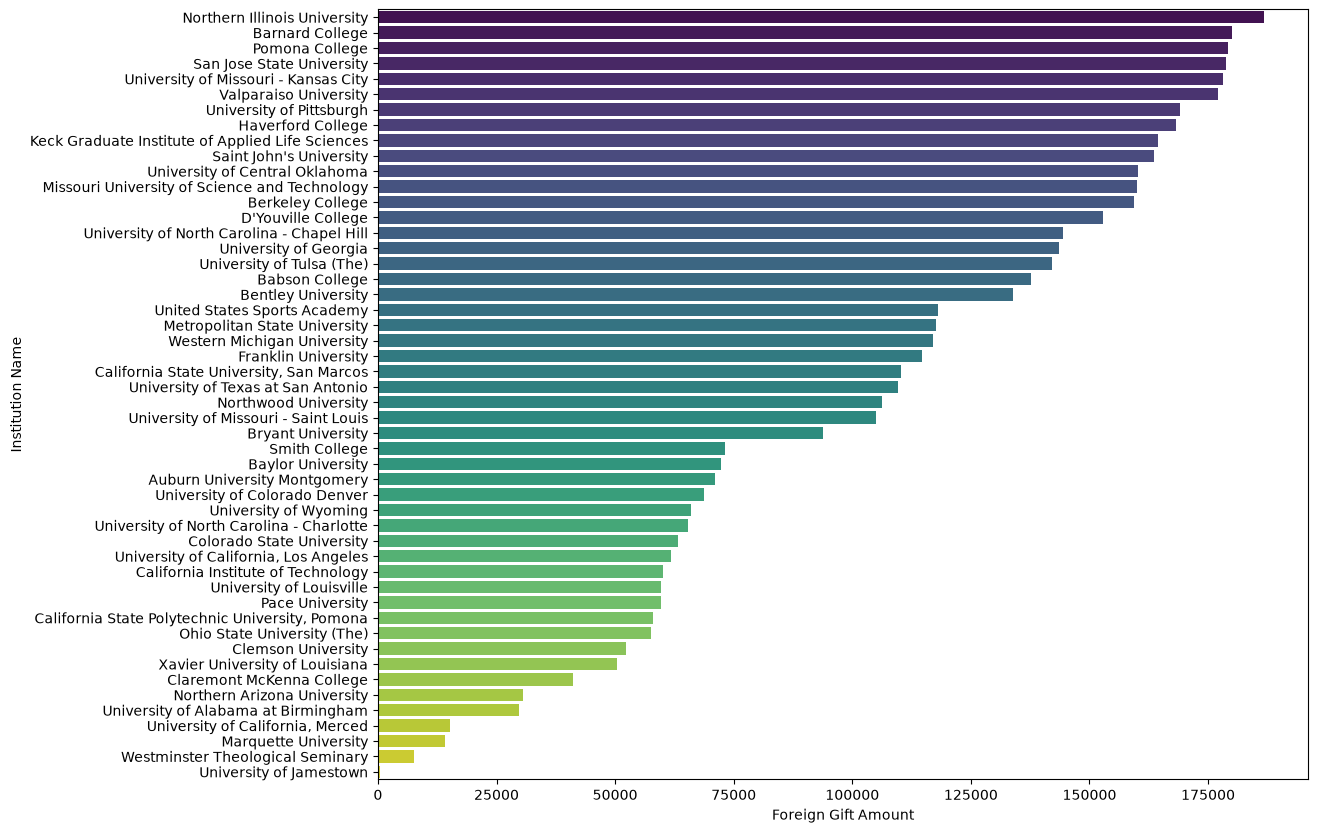

In [9]:
bottom_50 = mean_gifts.tail(50).reset_index()
plt.figure(figsize=(12, 10))
sns.barplot(
    data = bottom_50,
    x="Foreign Gift Amount",
    y="Institution Name",
    palette="viridis",
)
plt.show()

In [10]:
print(df['Foreign Gift Amount'].skew())
print(df['Foreign Gift Amount'].describe())

18.444925856833965
count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64


Note that there are far too many institutions to show all of them on a plot, I chose as many as I could while keeping the actual names visible. I wanted to show a wide range so I picked the top 45 and the  bottom 15. 

The mean is much higher than the median. This indicates the distribution of the data is extremely right skewed, which is supported by the max being several times larger than the 3rd quartile. This is due to a select few institutions having a much higher average gift amount than the others. Additionally, as indicated by the plots, the institutions with the lowest average gifts are far lower than the top of the distribution and are much more numerous. Even the 50th lowest institution has an average gift amount that is 5 times lower than the 45th highest average institution. 

## Question 7: What is the largest flow of a single country to a single institution?

In [11]:
pd.crosstab(
    index=df['Institution Name'],
    columns=df['Country of Giftor'],
    values=df['Foreign Gift Amount'],
    aggfunc='sum'
)


Country of Giftor,AFGHANISTAN,AMERICAN SAMOA,ANGOLA,ANTIGUA,ARGENTINA,ARMENIA,AUSTRALIA,AUSTRIA,AZERBAIJAN,BAHAMAS,...,UNITED NATIONS,URUGUAY,USA,VENEZUELA,VIETNAM,VIRGIN ISLANDS (BRITISH),WALES,YEMEN,ZAMBIA,ZIMBABWE
Institution Name,,,,,,,,,,,,,,,,,,,,,
Adelphi University,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Albert Einstein College of Medicine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alfred University,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
American University (The),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amherst College,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wright State University,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Xavier University of Louisiana,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Yale University,NaN,NaN,NaN,NaN,NaN,NaN,3382524.0,799635.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2858666.0,NaN,NaN,NaN,298000.0


In [12]:
df.groupby(['Institution Name', 'Country of Giftor'])['Foreign Gift Amount'].sum().sort_values(ascending=False)

Institution Name                       Country of Giftor   
Cornell University                     QATAR                   1018473315
Carnegie Mellon University             BERMUDA                  750000000
Texas A&M University                   QATAR                    504099350
Carnegie Mellon University             QATAR                    425410702
Georgetown University                  QATAR                    327128310
                                                                  ...    
Johns Hopkins University               CAYMAN ISLANDS (THE)            10
Westminster Theological Seminary       TRINIDAD                        10
                                       UNITED NATIONS                  10
University of California, Los Angeles  ERITREA                          3
University of California, Merced       MEXICO                           1
Name: Foreign Gift Amount, Length: 2685, dtype: int64

In [16]:
import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

#giftor = 'Giftor Name'
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

The largest flow from a single country to a single institution is from Qatar to Cornell University.

## Question 8: Which are the top giftors to US academic institutions?

In [17]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False)

Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
                   ...    
IRAN                    80
ST. LUCIA               50
CROATIA                 26
SLOVAKIA                20
ERITREA                  3
Name: Foreign Gift Amount, Length: 155, dtype: int64

The largest giftors of Qatar, the UK (includes Bermuda and England), China, and Saudi Arabia.